<a href="https://colab.research.google.com/github/nisaa783/practical-statistics-for-data-scientists_Anisa-Khasanah/blob/main/Chapter_6_Statistical_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Statistical Machine Learning

Statistik tradisional dan *Machine Learning* (ML) memiliki akar yang sama, namun pendekatan ML sering kali lebih fokus pada performa prediktif (*prediction accuracy*) menggunakan algoritma berbasis pembelajaran data otomatis. Bab ini membahas algoritma non-parametric, teknik *K-Nearest Neighbors*, *Bagging*, *Boosting*, serta evaluasi model lanjutan.

---

## 1. K-Nearest Neighbors (KNN)
* **Definisi:** Algoritma *instance-based* (atau *lazy learning*) yang memprediksi label atau nilai dari suatu data baru berdasarkan kedekatannya dengan $K$ tetangga terdekat dalam ruang fitur.
* **Metrik Jarak:** Biasanya menggunakan jarak Euclidean atau Manhattan untuk mengukur "kedekatan" antar titik data.
* **Hyperparameter $K$:**
  * Jika $K$ terlalu kecil (misal $K=1$), model sangat sensitif terhadap *noise* (*overfitting*).
  * Jika $K$ terlalu besar, batas keputusan menjadi terlalu halus dan mengabaikan pola lokal (*underfitting*).

---

## 2. Tree Models, Bagging, dan Random Forest
* **Decision Trees:** Membagi data secara berulang berdasarkan aturan keputusan fitur. Pohon tunggal sangat rentan terhadap *overfitting* terhadap data latih.
* **Bagging (Bootstrap Aggregating):** Teknik ensemble di mana kita melatih banyak pohon keputusan secara paralel menggunakan sampel *bootstrap* yang berbeda, lalu menggabungkan hasilnya (rata-rata untuk regresi, mayoritas voting untuk klasifikasi).
* **Random Forest:** Pengembangan dari *Bagging* di mana pada setiap pemisahan simpul (*split*), algoritma hanya memilih subset fitur secara acak untuk mengurangi korelasi antar pohon dan meningkatkan akurasi.

---

## 3. Boosting (Gradient Boosting / XGBoost)
* **Definisi:** Teknik *ensemble* sekuensial di mana setiap model baru dilatih untuk memperbaiki kesalahan (*residuals*) dari model sebelumnya.
* **Prinsip Kerja:** Menggabungkan model-model lemah (*weak learners*, biasanya pohon keputusan dangkal) secara berurutan agar model akhir menjadi prediktor yang sangat kuat (*strong learner*).

--- 5 Baris Pertama Dataset ML ---


,outcome,payment_inc_ratio,dti
0,target,9.00000,22.50
1,default,5.46933,21.33
2,paid off,6.90294,8.97
3,paid off,11.14800,1.83
4,default,3.72120,10.81



--- Evaluasi Model K-Nearest Neighbors (KNN) ---
              precision    recall  f1-score   support

           0       0.43      0.67      0.52        27
           1       0.53      0.29      0.38        34

    accuracy                           0.46        61
   macro avg       0.48      0.48      0.45        61
weighted avg       0.48      0.46      0.44        61


--- Evaluasi Model Random Forest ---
              precision    recall  f1-score   support

           0       0.43      0.56      0.48        27
           1       0.54      0.41      0.47        34

    accuracy                           0.48        61
   macro avg       0.48      0.48      0.48        61
weighted avg       0.49      0.48      0.47        61



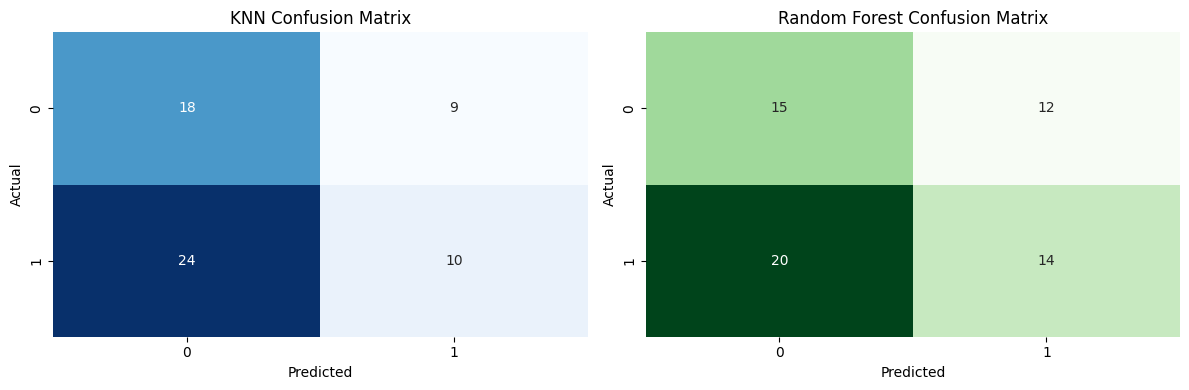

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 1. Menarik Dataset dari GitHub
# ==========================================
# Menggunakan dataset 'loan200.csv' untuk pemodelan Machine Learning (KNN & Random Forest)
url = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/loan200.csv"
loans_ml = pd.read_csv(url)

print("--- 5 Baris Pertama Dataset ML ---")
display(loans_ml.head())

# ==========================================
# 2. Persiapan Data (Data Preparation)
# ==========================================
X = loans_ml[['payment_inc_ratio', 'dti']]
y = loans_ml['outcome'].apply(lambda x: 1 if x == 'default' else 0)

# Membagi data menjadi training set (70%) dan testing set (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ==========================================
# 3. Model 1: K-Nearest Neighbors (KNN)
# ==========================================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("\n--- Evaluasi Model K-Nearest Neighbors (KNN) ---")
print(classification_report(y_test, y_pred_knn))

# ==========================================
# 4. Model 2: Random Forest Classifier
# ==========================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n--- Evaluasi Model Random Forest ---")
print(classification_report(y_test, y_pred_rf))

# ==========================================
# 5. Visualisasi Perbandingan Akurasi (Confusion Matrix)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix KNN
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('KNN Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()